## ⚽📊 Evaluating Passing Decisions Using xPass, xThreat & Machine Learning

**Competition:** Premier League (Season 2024/25)  
**Data:** SkillCorner Dynamic Events Data  
**Purpose:** Evaluate passing decisions by estimating the value of all available passing options  
**Methods:** Pass Completion Modelling (xPass), Expected Threat (xThreat), Gradient Boosting Models, Neural Networks  
**Author:** [Victoria Friss de Kereki](https://www.linkedin.com/in/victoria-friss-de-kereki/)

---

**Notebook first written:** `14/03/2026`  
**Last updated:** `18/03/2026`  

---

> Passing is the most common action in football, yet evaluating whether a player made the best decision in possession is difficult.
>
> Using SkillCorner Dynamic Events Data from the 2024/25 Premier League season, this notebook estimates the value of all available passing options for each possession event.
>
> A machine learning model predicts pass completion probability (xPass) using spatial and contextual features. This probability is combined with expected threat (xThreat) to estimate the expected value of each potential pass.
>
> By comparing the value of the pass that was played to the best available option, we can quantify decision quality and analyse which players consistently make better passing decisions.

## Imports & Display Settings

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set(style="whitegrid", font_scale=1.2)

## Load data

### Events data

In [2]:
# Matches
matches = pd.read_parquet(r"Datasets/SkillCorner Premier League 24-25 data/matches_clean.parquet")

# Team lookup table
team_lookup = pd.concat([
    matches[["home_team_id","home_team_name"]].rename(columns={"home_team_id":"team_id","home_team_name":"team_name"}),
    matches[["away_team_id","away_team_name"]].rename(columns={"away_team_id":"team_id","away_team_name":"team_name"})
]).drop_duplicates()

# Event files
folder = Path(r"Datasets/SkillCorner Premier League 24-25 data\dynamic_events_pl_24\dynamic")
dfs = [pd.read_parquet(file) for file in folder.glob("*.parquet")]
events = pd.concat(dfs, ignore_index=True)

print(f"Total events: {len(events)}, Unique matches: {events['match_id'].nunique()}")

Total events: 1811078, Unique matches: 378


In [3]:
# Basic dataset information
print("Number of rows:", events.shape[0])
print("Number of columns:", events.shape[1])

# Display column names
events.columns

Number of rows: 1811078
Number of columns: 294


Index(['event_id', 'index', 'match_id', 'frame_start', 'frame_end',
       'frame_physical_start', 'time_start', 'time_end', 'minute_start',
       'second_start',
       ...
       'xloss_player_possession_end', 'xloss_player_possession_max',
       'xshot_player_possession_start', 'xshot_player_possession_end',
       'xshot_player_possession_max', 'is_player_possession_start_matched',
       'is_player_possession_end_matched', 'is_previous_pass_matched',
       'is_pass_reception_matched', 'fully_extrapolated'],
      dtype='object', length=294)

In [4]:
events["event_type"].value_counts().head(10)

event_type
passing_option        939059
player_possession     362853
on_ball_engagement    326100
off_ball_run          183066
Name: count, dtype: int64

In [5]:
events.head()

,event_id,index,match_id,frame_start,frame_end,frame_physical_start,time_start,time_end,minute_start,second_start,...,xloss_player_possession_end,xloss_player_possession_max,xshot_player_possession_start,xshot_player_possession_end,xshot_player_possession_max,is_player_possession_start_matched,is_player_possession_end_matched,is_previous_pass_matched,is_pass_reception_matched,fully_extrapolated
0,8_0,0,1650385,52,52,NaN,00:04.2,00:04.2,0,4,...,NaN,NaN,NaN,NaN,NaN,True,True,None,True,False
1,1_0,1,1650385,59,72,NaN,00:04.9,00:06.2,0,4,...,NaN,NaN,NaN,NaN,NaN,True,True,None,None,None
2,8_1,2,1650385,62,71,NaN,00:05.2,00:06.1,0,5,...,NaN,NaN,NaN,NaN,NaN,True,True,True,True,False
3,7_0,3,1650385,62,70,NaN,00:05.2,00:06.0,0,5,...,NaN,NaN,NaN,NaN,NaN,True,True,None,None,False
4,9_0,4,1650385,62,71,59.0,00:04.9,00:06.1,0,4,...,0.03,0.092,0.0,0.0,0.0,True,True,True,True,None


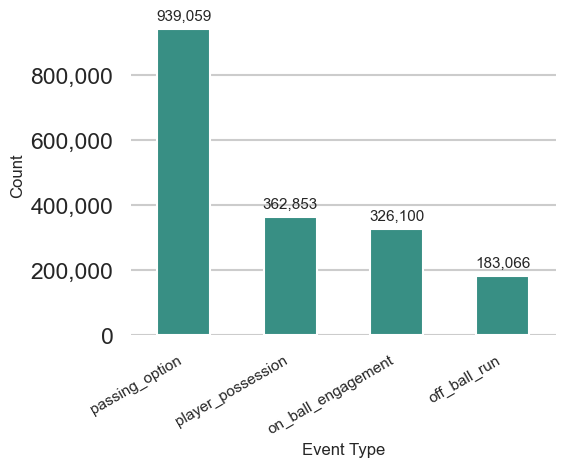

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Style and context
sns.set_style("whitegrid")
sns.set_context("talk")

# Example: top 4 event types (replace with your actual data)
top_events = events["event_type"].value_counts().nlargest(4).index

# Figure size: narrower height, wider width for few bars
plt.figure(figsize=(6, 5))

# Vertical bar plot
ax = sns.countplot(
    data=events,
    x="event_type",
    order=top_events,
    color="#2a9d8f",  # modern teal colour
    width=0.5          # narrower bars for nice spacing
)

# Add counts on top of bars with thousands separator
max_count = events["event_type"].value_counts().max()
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + max_count * 0.02,  # slightly above bar
        f'{int(height):,}',          # thousands separator
        ha='center', va='bottom', fontsize=11
    )

# Format y-axis with thousands separator
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

# Labels
ax.set_xlabel("Event Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

# Rotate x labels slightly if needed
plt.xticks(rotation=30, ha='right', fontsize=11)

# Remove unnecessary spines
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### Players match data

In [7]:
# LOAD PLAYERS MATCH DATA

players_match = pd.read_parquet(
    "Datasets/SkillCorner Premier League 24-25 data/players_match.parquet"
)

players_match["player_id"] = players_match["id"]
players_match["player_name"] = players_match["short_name"]
players_match["position"] = players_match["player_role_acronym"]
players_match["position_group"] = players_match["player_role_position_group"]


# MINUTES SUMMARY PER PLAYER

minutes_summary = (
    players_match
    .groupby(["player_id","player_name"])
    .agg(
        minutes_tip=("playing_time_total_minutes_tip","sum"),
        minutes_otip=("playing_time_total_minutes_otip","sum"),
        minutes_played=("playing_time_total_minutes_played","sum")
    )
    .reset_index()
)


# MINUTES PLAYED BY POSITION

position_minutes = (
    players_match
    .groupby(
        ["player_id","player_name","position","position_group"],
        as_index=False
    )
    .agg(
        minutes_played=("playing_time_total_minutes_played","sum")
    )
)

position_minutes_sorted = position_minutes.sort_values(
    ["player_id","minutes_played"],
    ascending=[True,False]
)


# FUNCTION TO GET MAIN POSITION (WITH SUB FIX)

def get_main_position(df):

    main_pos = df.iloc[0]["position"]
    pos_group = df.iloc[0]["position_group"]

    # Fix substitute classification
    if main_pos == "SUB" and len(df) > 1:
        main_pos = df.iloc[1]["position"]
        pos_group = df.iloc[1]["position_group"]

    # Fix GK group naming
    if main_pos == "GK":
        pos_group = "Goalkeeper"

    return pd.Series({
        "main_position": main_pos,
        "position_group": pos_group
    })


main_positions = (
    position_minutes_sorted
    .groupby("player_id")
    .apply(get_main_position)
    .reset_index()
)


# FINAL PLAYER DATASET

players = (
    minutes_summary
    .merge(main_positions, on="player_id", how="left")
)


# Prevent division by zero later
players["minutes_played"] = players["minutes_played"].replace(0, np.nan)

print(players.shape)
players.head()

(686, 7)


C:\Users\vicky\AppData\Local\Temp\ipykernel_13640\3181473640.py:71: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_main_position)


,player_id,player_name,minutes_tip,minutes_otip,minutes_played,main_position,position_group
0,82,A. Cresswell,240.62,280.86,937.72,LCB,Central Defender
1,124,A. Doucouré,649.13,886.57,2792.56,AM,Midfield
2,168,A. Armstrong,395.59,356.80,1381.38,CF,Center Forward
3,192,A. Lallana,125.61,124.60,429.45,LM,Midfield
4,209,A. Smith,436.55,478.56,1753.84,RB,Full Back


## Player Passing Analysis

In [8]:
# PASSING DECISION & OPTION CREATION ANALYSIS
# xThreat × xPass

# 1️⃣ Passing options dataset

passing_options = events[events["event_type"] == "passing_option"].copy()

# Identify passer vs receiver

passing_options["passer_id"] = passing_options["player_in_possession_id"]
passing_options["passer_name"] = passing_options["player_in_possession_name"]

passing_options["receiver_id"] = passing_options["player_id"]
passing_options["receiver_name"] = passing_options["player_name"]


# 2️⃣ Pass value

passing_options["pass_value"] = (passing_options["xthreat"] * passing_options["xpass_completion"])


# 3️⃣ Best option available in each pass

best_option = (
    passing_options
    .groupby(
        ["match_id","associated_player_possession_event_id"],
        as_index=False
    )
    .agg(best_pass_value=("pass_value","max"))
)

passing_options = passing_options.merge(
    best_option,
    on=["match_id","associated_player_possession_event_id"],
    how="left"
)

# ============================================
# REMOVE TRIVIAL PASSING DECISIONS
# Only keep possessions with >1 passing option
# ============================================

option_counts = (
    passing_options
    .groupby(["match_id","associated_player_possession_event_id"])
    .size()
    .reset_index(name="n_options")
)

passing_options = passing_options.merge(
    option_counts,
    on=["match_id","associated_player_possession_event_id"],
    how="left"
)

# Keep only real decision moments
passing_options = passing_options[
    passing_options["n_options"] > 1
].copy()


# 4️⃣ Extract actual passes

chosen_passes = passing_options[
    passing_options["targeted"] == True
].copy()


print("Total passes analysed:", len(chosen_passes))

Total passes analysed: 265706


In [9]:
# Remove irrelevant columns

passing_options = passing_options.dropna(axis=1, how="all")
print("Remaining columns:", len(passing_options.columns))

Remaining columns: 154


In [10]:
columns_keep = [

    # identifiers
    "match_id",
    "event_id",
    "associated_player_possession_event_id",

    # passer / receiver
    "passer_id",
    "passer_name",
    "receiver_id",
    "receiver_name",

    # team
    "team_id",
    "team_shortname",

    # timing
    "minute_start",
    "second_start",
    "period",

    # locations
    "x_start",
    "y_start",
    "x_end",
    "y_end",

    # spatial context
    "third_start",
    "third_end",
    "channel_start",
    "channel_end",

    # pass characteristics
    "pass_distance",
    "pass_angle",
    "pass_direction",
    "pass_ahead",

    # defensive context
    "n_opponents_ahead_player_in_possession_pass_moment",
    "n_opponents_bypassed",

    # model outputs
    "xpass_completion",
    "xthreat",
    "pass_value",
    "best_pass_value",
    "passing_option_score",

    # pass decision
    "targeted",
    "received",
    "received_in_space",
    "dangerous",
    "difficult_pass_target",

    # option context
    "n_simultaneous_passing_options"
]

passing_options = passing_options[columns_keep]

print("Columns kept:", len(passing_options.columns))

Columns kept: 37


In [11]:
passing_options.head(10)

,match_id,event_id,associated_player_possession_event_id,passer_id,passer_name,receiver_id,receiver_name,team_id,team_shortname,minute_start,...,xthreat,pass_value,best_pass_value,passing_option_score,targeted,received,received_in_space,dangerous,difficult_pass_target,n_simultaneous_passing_options
0,1650385,7_0,8_1,13068.0,S. Lukić,12941,E. Smith Rowe,48,Fulham,0,...,0.0013,0.001275,0.001300,0.7928,False,False,None,False,False,3.0
1,1650385,7_1,8_1,13068.0,S. Lukić,5794,K. Tete,48,Fulham,0,...,0.0001,0.000100,0.001300,0.9321,False,False,None,False,False,3.0
2,1650385,7_2,8_1,13068.0,S. Lukić,4504,I. Diop,48,Fulham,0,...,0.0000,0.000000,0.001300,0.7076,True,True,True,False,False,3.0
3,1650385,7_3,8_1,13068.0,S. Lukić,12168,Adama Traoré,48,Fulham,0,...,0.0021,0.001300,0.001300,0.7342,False,False,None,False,True,3.0
4,1650385,7_4,8_2,4504.0,I. Diop,32264,C. Bassey,48,Fulham,0,...,0.0000,0.000000,0.001429,0.8665,False,False,None,False,False,1.0
5,1650385,7_5,8_2,4504.0,I. Diop,5794,K. Tete,48,Fulham,0,...,0.0003,0.000283,0.001429,0.8669,False,False,None,False,False,4.0
6,1650385,7_6,8_2,4504.0,I. Diop,11438,Andreas Pereira,48,Fulham,0,...,0.0007,0.000682,0.001429,0.7970,False,False,None,False,False,3.0
7,1650385,7_7,8_2,4504.0,I. Diop,12168,Adama Traoré,48,Fulham,0,...,0.0020,0.000858,0.001429,0.9208,True,True,False,False,True,3.0
8,1650385,7_8,8_2,4504.0,I. Diop,32862,Rodrigo Muniz,48,Fulham,0,...,0.0028,0.001429,0.001429,0.8554,False,False,None,False,True,3.0
9,1650385,7_9,8_3,12168.0,Adama Traoré,5794,K. Tete,48,Fulham,0,...,0.0020,0.001842,0.005579,0.9390,False,False,None,False,False,2.0


In [12]:
chosen_passes = chosen_passes[columns_keep]
chosen_passes.head()

,match_id,event_id,associated_player_possession_event_id,passer_id,passer_name,receiver_id,receiver_name,team_id,team_shortname,minute_start,...,xthreat,pass_value,best_pass_value,passing_option_score,targeted,received,received_in_space,dangerous,difficult_pass_target,n_simultaneous_passing_options
2,1650385,7_2,8_1,13068.0,S. Lukić,4504,I. Diop,48,Fulham,0,...,0.0000,0.000000,0.001300,0.7076,True,True,True,False,False,3.0
7,1650385,7_7,8_2,4504.0,I. Diop,12168,Adama Traoré,48,Fulham,0,...,0.0020,0.000858,0.001429,0.9208,True,True,False,False,True,3.0
15,1650385,7_15,8_4,70672.0,K. Mainoo,6847,M. Rashford,31,Manchester U,0,...,0.0028,0.001519,0.002538,0.9013,True,True,True,False,True,3.0
19,1650385,7_19,8_9,12380.0,N. Mazraoui,24305,A. Diallo,31,Manchester U,1,...,0.0006,0.000582,0.002118,0.9305,True,True,True,False,False,1.0
24,1650385,7_24,8_10,24305.0,A. Diallo,11383,H. Maguire,31,Manchester U,1,...,0.0000,0.000000,0.002338,0.8684,True,True,True,False,False,4.0


In [13]:
# DECISION METRICS

chosen_passes["decision_quality"] = (
    chosen_passes["pass_value"] /
    chosen_passes["best_pass_value"].replace(0, np.nan)
)

# If pass is within 95% of best, it is still considered the best.
chosen_passes["chose_best"] = (
    chosen_passes["pass_value"] >=
    chosen_passes["best_pass_value"] * 0.95
)


# EXECUTION METRICS


chosen_passes["actual_completion"] = (
    chosen_passes["received"] == True
).astype(int)

chosen_passes["completion_minus_xpass"] = (
    chosen_passes["actual_completion"] -
    chosen_passes["xpass_completion"]
)

In [14]:
chosen_passes.head()

,match_id,event_id,associated_player_possession_event_id,passer_id,passer_name,receiver_id,receiver_name,team_id,team_shortname,minute_start,...,targeted,received,received_in_space,dangerous,difficult_pass_target,n_simultaneous_passing_options,decision_quality,chose_best,actual_completion,completion_minus_xpass
2,1650385,7_2,8_1,13068.0,S. Lukić,4504,I. Diop,48,Fulham,0,...,True,True,True,False,False,3.0,0.000000,False,1,0.0011
7,1650385,7_7,8_2,4504.0,I. Diop,12168,Adama Traoré,48,Fulham,0,...,True,True,False,False,True,3.0,0.600627,False,1,0.5709
15,1650385,7_15,8_4,70672.0,K. Mainoo,6847,M. Rashford,31,Manchester U,0,...,True,True,True,False,True,3.0,0.598392,False,1,0.4575
19,1650385,7_19,8_9,12380.0,N. Mazraoui,24305,A. Diallo,31,Manchester U,1,...,True,True,True,False,False,1.0,0.275020,False,1,0.0294
24,1650385,7_24,8_10,24305.0,A. Diallo,11383,H. Maguire,31,Manchester U,1,...,True,True,True,False,False,4.0,0.000000,False,1,0.0036


In [15]:
# PLAYER PASSING METRICS

passer_metrics = (
    chosen_passes
    .groupby(["passer_id","passer_name","team_shortname"])
    .agg(
        passes_attempted=("pass_value","count"),

        # decision making
        avg_decision_quality=("decision_quality","mean"),
        chose_best_rate=("chose_best","mean"),
        chose_best_count=("chose_best","sum"),
        chose_not_best_count=("chose_best", lambda x: (~x).sum()),

        # execution
        completion_minus_xpass_per_pass=("completion_minus_xpass","mean"),
        completion_minus_xpass_total=("completion_minus_xpass","sum"),

        # value
        total_pass_value=("pass_value","sum"),
        avg_pass_value=("pass_value","mean"),
    )
    .reset_index()
)

In [16]:
passer_metrics.head()

,passer_id,passer_name,team_shortname,passes_attempted,avg_decision_quality,chose_best_rate,chose_best_count,chose_not_best_count,completion_minus_xpass_per_pass,completion_minus_xpass_total,total_pass_value,avg_pass_value
0,82.0,A. Cresswell,West Ham,432,0.606253,0.379630,164,268,0.000583,0.2518,1.267649,0.002934
1,124.0,A. Doucouré,Everton,720,0.624121,0.373611,269,451,-0.005271,-3.7950,5.637928,0.007830
2,168.0,A. Armstrong,Southampton,224,0.576774,0.290179,65,159,-0.040264,-9.0192,2.105486,0.009399
3,192.0,A. Lallana,Southampton,217,0.640830,0.373272,81,136,0.015773,3.4227,1.282473,0.005910
4,209.0,A. Smith,Bournemouth,397,0.545485,0.299748,119,278,-0.004091,-1.6242,1.558356,0.003925


In [17]:
# MERGE PLAYER DATA (TIP minutes)

passer_metrics = passer_metrics.merge(
    players,
    left_on="passer_id",
    right_on="player_id",
    how="left"
)


# NORMALISE PER 90 TIP

passer_metrics["passes_per90_tip"] = (
    passer_metrics["passes_attempted"] /
    passer_metrics["minutes_tip"] * 90
)

passer_metrics["pass_value_per90_tip"] = (
    passer_metrics["total_pass_value"] /
    passer_metrics["minutes_tip"] * 90
)


# FILTER SMALL SAMPLE PLAYERS

passers_filtered = passer_metrics[
    passer_metrics["passes_attempted"] >= 200
].copy()

passer_metrics.head()

,passer_id,passer_name,team_shortname,passes_attempted,avg_decision_quality,chose_best_rate,chose_best_count,chose_not_best_count,completion_minus_xpass_per_pass,completion_minus_xpass_total,...,avg_pass_value,player_id,player_name,minutes_tip,minutes_otip,minutes_played,main_position,position_group,passes_per90_tip,pass_value_per90_tip
0,82.0,A. Cresswell,West Ham,432,0.606253,0.379630,164,268,0.000583,0.2518,...,0.002934,82,A. Cresswell,240.62,280.86,937.72,LCB,Central Defender,161.582578,0.474143
1,124.0,A. Doucouré,Everton,720,0.624121,0.373611,269,451,-0.005271,-3.7950,...,0.007830,124,A. Doucouré,649.13,886.57,2792.56,AM,Midfield,99.825921,0.781682
2,168.0,A. Armstrong,Southampton,224,0.576774,0.290179,65,159,-0.040264,-9.0192,...,0.009399,168,A. Armstrong,395.59,356.80,1381.38,CF,Center Forward,50.961854,0.479016
3,192.0,A. Lallana,Southampton,217,0.640830,0.373272,81,136,0.015773,3.4227,...,0.005910,192,A. Lallana,125.61,124.60,429.45,LM,Midfield,155.481251,0.918897
4,209.0,A. Smith,Bournemouth,397,0.545485,0.299748,119,278,-0.004091,-1.6242,...,0.003925,209,A. Smith,436.55,478.56,1753.84,RB,Full Back,81.846295,0.321274


In [18]:
# RECEIVER PASSING OPTION METRICS

receiver_metrics = (
    passing_options
    .groupby(["receiver_id","receiver_name","team_shortname"])
    .agg(

        # availability
        passing_options_available=("receiver_id","count"),

        # how often teammates choose them
        times_targeted=("targeted","sum"),

        # rate they are chosen when available
        option_selection_rate=("targeted","mean"),

        # value of those options
        total_option_value=("pass_value","sum"),
        avg_option_value=("pass_value","mean"),

        # threat potential
        total_xthreat_available=("xthreat","sum"),
        avg_xthreat_available=("xthreat","mean"),

        # pass difficulty
        avg_xpass_passing_option_created=("xpass_completion","mean"),
    )
    .reset_index()
)

In [19]:
receiver_metrics.head()

,receiver_id,receiver_name,team_shortname,passing_options_available,times_targeted,option_selection_rate,total_option_value,avg_option_value,total_xthreat_available,avg_xthreat_available,avg_xpass_passing_option_created
0,82,A. Cresswell,West Ham,891,328,0.368126,2.190362,0.002458,2.7675,0.003106,0.945276
1,124,A. Doucouré,Everton,3221,831,0.257994,27.344599,0.008489,47.1134,0.014627,0.742259
2,168,A. Armstrong,Southampton,1486,358,0.240915,18.192065,0.012242,34.5610,0.023258,0.678395
3,192,A. Lallana,Southampton,703,217,0.308677,3.922228,0.005579,5.4707,0.007782,0.866358
4,209,A. Smith,Bournemouth,1396,370,0.265043,5.426252,0.003887,7.1842,0.005146,0.901801


In [20]:
# MERGE PLAYER DATA (TIP minutes)

receiver_metrics = receiver_metrics.merge(
    players,
    left_on="receiver_id",
    right_on="player_id",
    how="left"
)


# NORMALISE PER 90 TIP

receiver_metrics["options_available_per90_tip"] = (
    receiver_metrics["passing_options_available"] /
    receiver_metrics["minutes_tip"] * 90
)

receiver_metrics["targets_received_per90_tip"] = (
    receiver_metrics["times_targeted"] /
    receiver_metrics["minutes_tip"] * 90
)

receiver_metrics["option_value_per90_tip"] = (
    receiver_metrics["total_option_value"] /
    receiver_metrics["minutes_tip"] * 90
)

receiver_metrics["xthreat_available_per90_tip"] = (
    receiver_metrics["total_xthreat_available"] /
    receiver_metrics["minutes_tip"] * 90
)


# FILTER SMALL SAMPLE PLAYERS

receivers_filtered = receiver_metrics[
    receiver_metrics["passing_options_available"] >= 200
].copy()

receiver_metrics.head()

,receiver_id,receiver_name,team_shortname,passing_options_available,times_targeted,option_selection_rate,total_option_value,avg_option_value,total_xthreat_available,avg_xthreat_available,...,player_name,minutes_tip,minutes_otip,minutes_played,main_position,position_group,options_available_per90_tip,targets_received_per90_tip,option_value_per90_tip,xthreat_available_per90_tip
0,82,A. Cresswell,West Ham,891,328,0.368126,2.190362,0.002458,2.7675,0.003106,...,A. Cresswell,240.62,280.86,937.72,LCB,Central Defender,333.264068,122.683069,0.819269,1.035138
1,124,A. Doucouré,Everton,3221,831,0.257994,27.344599,0.008489,47.1134,0.014627,...,A. Doucouré,649.13,886.57,2792.56,AM,Midfield,446.582349,115.21575,3.791250,6.532137
2,168,A. Armstrong,Southampton,1486,358,0.240915,18.192065,0.012242,34.5610,0.023258,...,A. Armstrong,395.59,356.80,1381.38,CF,Center Forward,338.077302,81.447964,4.138845,7.862914
3,192,A. Lallana,Southampton,703,217,0.308677,3.922228,0.005579,5.4707,0.007782,...,A. Lallana,125.61,124.60,429.45,LM,Midfield,503.701935,155.481251,2.810290,3.919775
4,209,A. Smith,Bournemouth,1396,370,0.265043,5.426252,0.003887,7.1842,0.005146,...,A. Smith,436.55,478.56,1753.84,RB,Full Back,287.802085,76.279922,1.118687,1.481109


## Result Tables & Visualisations

In [21]:
# ============================================
# TABLE 1 — Best Passing Decision Makers
# Players who most frequently choose the highest-value passing option
# ============================================

best_decision_makers = (
    passers_filtered
    .sort_values("chose_best_rate", ascending=False)
    [["passer_name","team_shortname","main_position", "position_group", "passes_attempted",
      "chose_best_rate","avg_decision_quality","pass_value_per90_tip"]]
    .head(15)
)

best_decision_makers

,passer_name,team_shortname,main_position,position_group,passes_attempted,chose_best_rate,avg_decision_quality,pass_value_per90_tip
79,M. Sels,Nottingham,GK,Goalkeeper,359,0.573816,0.753177,0.045281
333,C. Chaplin,Ipswich Town,AM,Midfield,225,0.475556,0.670368,0.764283
58,J. Pickford,Everton,GK,Goalkeeper,759,0.463768,0.634542,0.082750
60,José Sá,Wolverhampton,GK,Goalkeeper,424,0.448113,0.607736,0.034555
271,M. Rogers,Aston Villa,RW,Wide Attacker,702,0.444444,0.697472,1.061080
304,Lucas Paquetà,West Ham,LM,Midfield,1121,0.443354,0.680275,1.104622
235,A. Ramsdale,Southampton,GK,Goalkeeper,609,0.443350,0.620728,0.055916
135,T. Alexander-Arnold,Liverpool,RB,Full Back,1368,0.440058,0.675371,1.017680
294,J. Mateta,Crystal Palace,CF,Center Forward,332,0.430723,0.667744,0.679142
103,I. Sarr,Crystal Palace,RW,Wide Attacker,583,0.430532,0.687890,1.300105


In [22]:
# ============================================
# TABLE 2 — Players Creating the Most Passing Value
# Players whose passes generate the highest expected attacking value
# ============================================

top_value_passers = (
    passers_filtered
    .sort_values("pass_value_per90_tip", ascending=False)
    [["passer_name","team_shortname",
      "main_position", "position_group", 
      "pass_value_per90_tip",
      "passes_per90_tip",
      "chose_best_rate"]]
    .head(15)
)

top_value_passers

,passer_name,team_shortname,main_position,position_group,pass_value_per90_tip,passes_per90_tip,chose_best_rate
82,Mohamed Salah,Liverpool,RW,Wide Attacker,1.397877,79.733545,0.393130
62,K. De Bruyne,Manchester City,AM,Midfield,1.392310,113.880215,0.374269
241,M. Ødegaard,Arsenal,RM,Midfield,1.364128,135.321802,0.334146
14,Bruno Fernandes,Manchester U,AM,Midfield,1.325447,153.679010,0.378752
103,I. Sarr,Crystal Palace,RW,Wide Attacker,1.300105,79.853290,0.430532
256,M. Damsgaard,Brentford FC,AM,Midfield,1.297924,123.585547,0.411141
5,A. Iwobi,Fulham,LW,Wide Attacker,1.271832,123.988504,0.382602
507,Y. Minteh,Brighton,RW,Wide Attacker,1.270923,67.988816,0.425287
154,C. Hudson-Odoi,Nottingham,LW,Wide Attacker,1.266464,121.924247,0.297376
269,H. Barnes,Newcastle,LF,Wide Attacker,1.252672,86.057143,0.408367


In [23]:
# ============================================
# TABLE 3 — Best Pass Execution (Completion vs xPass)
# Players who complete more passes than expected by the xPass model
# ============================================

best_executors = (
    passers_filtered
    .sort_values("completion_minus_xpass_per_pass", ascending=False)
    [["passer_name","team_shortname", "main_position", "position_group", 
      "passes_attempted",
      "completion_minus_xpass_per_pass",
      "chose_best_rate"]]
    .head(15)
)

best_executors

,passer_name,team_shortname,main_position,position_group,passes_attempted,completion_minus_xpass_per_pass,chose_best_rate
190,K. Havertz,Arsenal,CF,Center Forward,377,0.060661,0.358090
199,R. Nelson,Fulham,LW,Wide Attacker,235,0.044782,0.255319
19,C. Nkunku,Chelsea,CF,Center Forward,273,0.040264,0.300366
160,I. Sangaré,Nottingham,RDM,Midfield,211,0.036561,0.350711
201,J. Sancho,Chelsea,LW,Wide Attacker,666,0.035179,0.322823
301,B. Saka,Arsenal,RF,Wide Attacker,582,0.031118,0.328179
343,N. Domínguez,Nottingham,RDM,Midfield,729,0.030073,0.359396
155,A. Tuanzebe,Ipswich Town,RB,Full Back,532,0.029840,0.319549
237,Pedro Neto,Chelsea,RW,Wide Attacker,684,0.029835,0.314327
37,Son Heung-Min,Tottenham,LF,Wide Attacker,742,0.027613,0.336927


In [24]:
# ============================================
# TABLE 4 — Players Creating the Most Passing Options
# Players who most frequently make themselves available for passes
# ============================================

top_option_creators = (
    receivers_filtered
    .sort_values("options_available_per90_tip", ascending=False)
    [["receiver_name","team_shortname", "main_position", "position_group", 
      "options_available_per90_tip",
      "targets_received_per90_tip",
      "option_selection_rate"]]
    .head(15)
)

top_option_creators

,receiver_name,team_shortname,main_position,position_group,options_available_per90_tip,targets_received_per90_tip,option_selection_rate
351,A. Irving,West Ham,LM,Midfield,545.616114,177.725118,0.325733
36,H. Reed,Fulham,RDM,Midfield,527.586207,105.039788,0.199095
268,E. Buendía,Aston Villa,AM,Midfield,526.221825,130.551216,0.248092
527,L. Miley,Newcastle,RM,Midfield,523.800511,143.938677,0.274797
567,J. Simpson-Pusey,Manchester City,RCB,Central Defender,522.972973,135.810811,0.25969
96,T. Cairney,Fulham,LDM,Midfield,514.242564,183.87381,0.357562
439,N. Broadhead,Ipswich Town,LW,Wide Attacker,509.834396,119.620558,0.234626
3,A. Lallana,Southampton,LM,Midfield,503.701935,155.481251,0.308677
48,J. Schlupp,Crystal Palace,AM,Midfield,491.939547,117.884131,0.239631
483,K. Mainoo,Manchester U,LM,Midfield,486.437011,120.985189,0.248717


In [25]:
# ============================================
# TABLE 5 — Most Valuable Passing Options Created
# Players whose movement creates the highest-value passing options
# ============================================

best_off_ball_value = (
    receivers_filtered
    .sort_values("option_value_per90_tip", ascending=False)
    [["receiver_name","team_shortname", "main_position", "position_group", 
      "option_value_per90_tip",
      "options_available_per90_tip",
      "targets_received_per90_tip"]]
    .head(15)
)

best_off_ball_value

,receiver_name,team_shortname,main_position,position_group,option_value_per90_tip,options_available_per90_tip,targets_received_per90_tip
488,Ali Al Hamadi,Ipswich Town,CF,Center Forward,8.967861,482.517483,142.657343
32,E. Ünal,Bournemouth,CF,Center Forward,8.275372,413.774740,130.203248
182,T. Awoniyi,Nottingham,CF,Center Forward,8.200024,408.106607,129.927818
15,C. Wilson,Newcastle,CF,Center Forward,8.098612,365.840755,91.261793
563,C. Obi,Manchester U,CF,Center Forward,7.897021,404.076004,75.850444
449,D. Jebbison,Bournemouth,CF,Center Forward,7.652618,370.675453,88.962109
358,D. Núñez,Liverpool,CF,Center Forward,7.532510,395.775181,87.287695
509,Igor Thiago,Brentford FC,CF,Center Forward,7.047726,357.316227,81.137309
27,Diogo Jota,Liverpool,CF,Center Forward,7.029416,419.385099,94.767946
466,J. Durán,Aston Villa,CF,Center Forward,6.983441,422.748624,104.550735


In [26]:
# ============================================
# TABLE 6 — Most Dangerous Receiving Positions
# Players who generate the most expected threat through their availability
# ============================================

dangerous_receivers = (
    receivers_filtered
    .sort_values("xthreat_available_per90_tip", ascending=False)
    [["receiver_name","team_shortname","main_position", "position_group", 
      "xthreat_available_per90_tip",
      "targets_received_per90_tip",
      "option_selection_rate"]]
    .head(15)
)

dangerous_receivers

,receiver_name,team_shortname,main_position,position_group,xthreat_available_per90_tip,targets_received_per90_tip,option_selection_rate
488,Ali Al Hamadi,Ipswich Town,CF,Center Forward,18.840839,142.657343,0.295652
182,T. Awoniyi,Nottingham,CF,Center Forward,18.161577,129.927818,0.318367
15,C. Wilson,Newcastle,CF,Center Forward,18.104356,91.261793,0.249458
32,E. Ünal,Bournemouth,CF,Center Forward,16.721133,130.203248,0.314672
563,C. Obi,Manchester U,CF,Center Forward,15.984998,75.850444,0.187713
358,D. Núñez,Liverpool,CF,Center Forward,15.671292,87.287695,0.220549
372,Evanilson,Bournemouth,CF,Center Forward,15.270081,94.445866,0.253824
399,N. Jackson,Chelsea,CF,Center Forward,14.721358,94.386256,0.261405
449,D. Jebbison,Bournemouth,CF,Center Forward,14.639703,88.962109,0.24
466,J. Durán,Aston Villa,CF,Center Forward,14.205217,104.550735,0.247312


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = {
    "Goalkeeper": "#6a4c93",
    "Central Defender": "#1982c4",
    "Full Back": "#4cc9f0",
    "Midfield": "#8ac926",
    "Center Forward": "#ff595e",
    "Wide Attacker": "#ff924c"
}

# Desired order
position_order = ["Goalkeeper", "Central Defender", "Full Back", "Midfield", "Wide Attacker", "Center Forward"]


# Position clusters for side-by-side plots
position_clusters = {
    "Goalkeeper": ["Goalkeeper"],
    "Defenders": ["Central Defender", "Full Back"],
    "Midfield": ["Midfield"],
    "Attackers": ["Center Forward", "Wide Attacker"]
}

In [90]:
def plot_generic_and_clusters(df, x, y, label_col, title, top_n_label=3, ref_lines=True):
    """
    Plots 1 generic scatter (all positions) and 4 cluster plots in 2x2 grid.
    Converts x and y to numeric to avoid dtype issues.
    Adds top N labels with dynamic offsets so labels stay close.
    Uses smaller legend labels and markers for the main plot.
    """
    df = df.copy()
    df[y] = pd.to_numeric(df[y], errors='coerce')
    df[x] = pd.to_numeric(df[x], errors='coerce')

    # --- Generic plot ---
    plt.figure(figsize=(10,7))
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue="position_group",
        palette=palette,
        hue_order=position_order,
        alpha=0.85,
        s=70
    )
    if ref_lines:
        plt.axhline(df[y].mean(), linestyle="--", color="grey")
        plt.axvline(df[x].mean(), linestyle="--", color="grey")

    # Calculate dynamic offsets
    x_offset = (df[x].max() - df[x].min()) * 0.01
    y_offset = (df[y].max() - df[y].min()) * 0.01

    # Label top N points
    topN = df.nlargest(top_n_label, y)
    for _, r in topN.iterrows():
        plt.text(r[x]+x_offset, r[y]+y_offset, r[label_col], fontsize=10, weight="bold")

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{title} (All Positions)")

    # Smaller legend
    plt.legend(title="Position Group", bbox_to_anchor=(1.02,1), loc="upper left",
               fontsize=12, title_fontsize=11, markerscale=1)

    plt.tight_layout()
    plt.show()

    # --- 4 cluster plots in 2x2 grid ---
    fig, axes = plt.subplots(2, 2, figsize=(16,12), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, (cluster_name, positions) in zip(axes, position_clusters.items()):
        cluster_df = df[df["position_group"].isin(positions)]

        sns.scatterplot(
            data=cluster_df,
            x=x,
            y=y,
            hue="position_group",
            palette=palette,
            hue_order=position_order,
            alpha=0.85,
            s=70,
            ax=ax
        )

        if ref_lines:
            ax.axhline(cluster_df[y].mean(), linestyle="--", color="grey")
            ax.axvline(cluster_df[x].mean(), linestyle="--", color="grey")

        # Dynamic offsets for this cluster
        x_offset = (cluster_df[x].max() - cluster_df[x].min()) * 0.01
        y_offset = (cluster_df[y].max() - cluster_df[y].min()) * 0.01

        topN = cluster_df.nlargest(top_n_label, y)
        for _, r in topN.iterrows():
            ax.text(r[x]+x_offset, r[y]+y_offset, r[label_col], fontsize=10, weight="bold")

        ax.set_title(f"{title} ({cluster_name})")
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.legend().remove()  # remove legend for cluster plots to save space

    plt.tight_layout()
    plt.show()

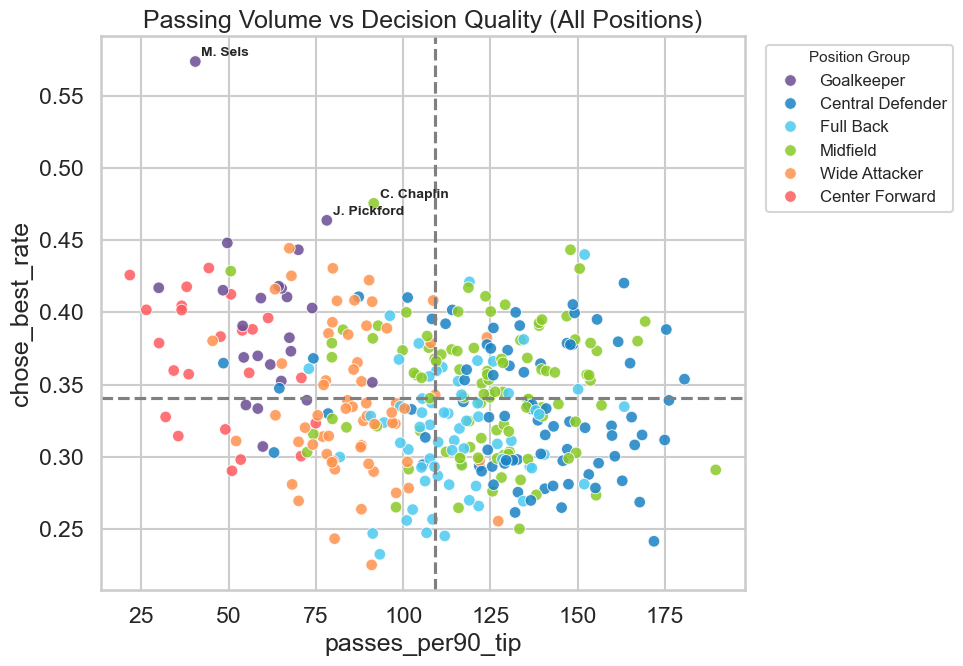

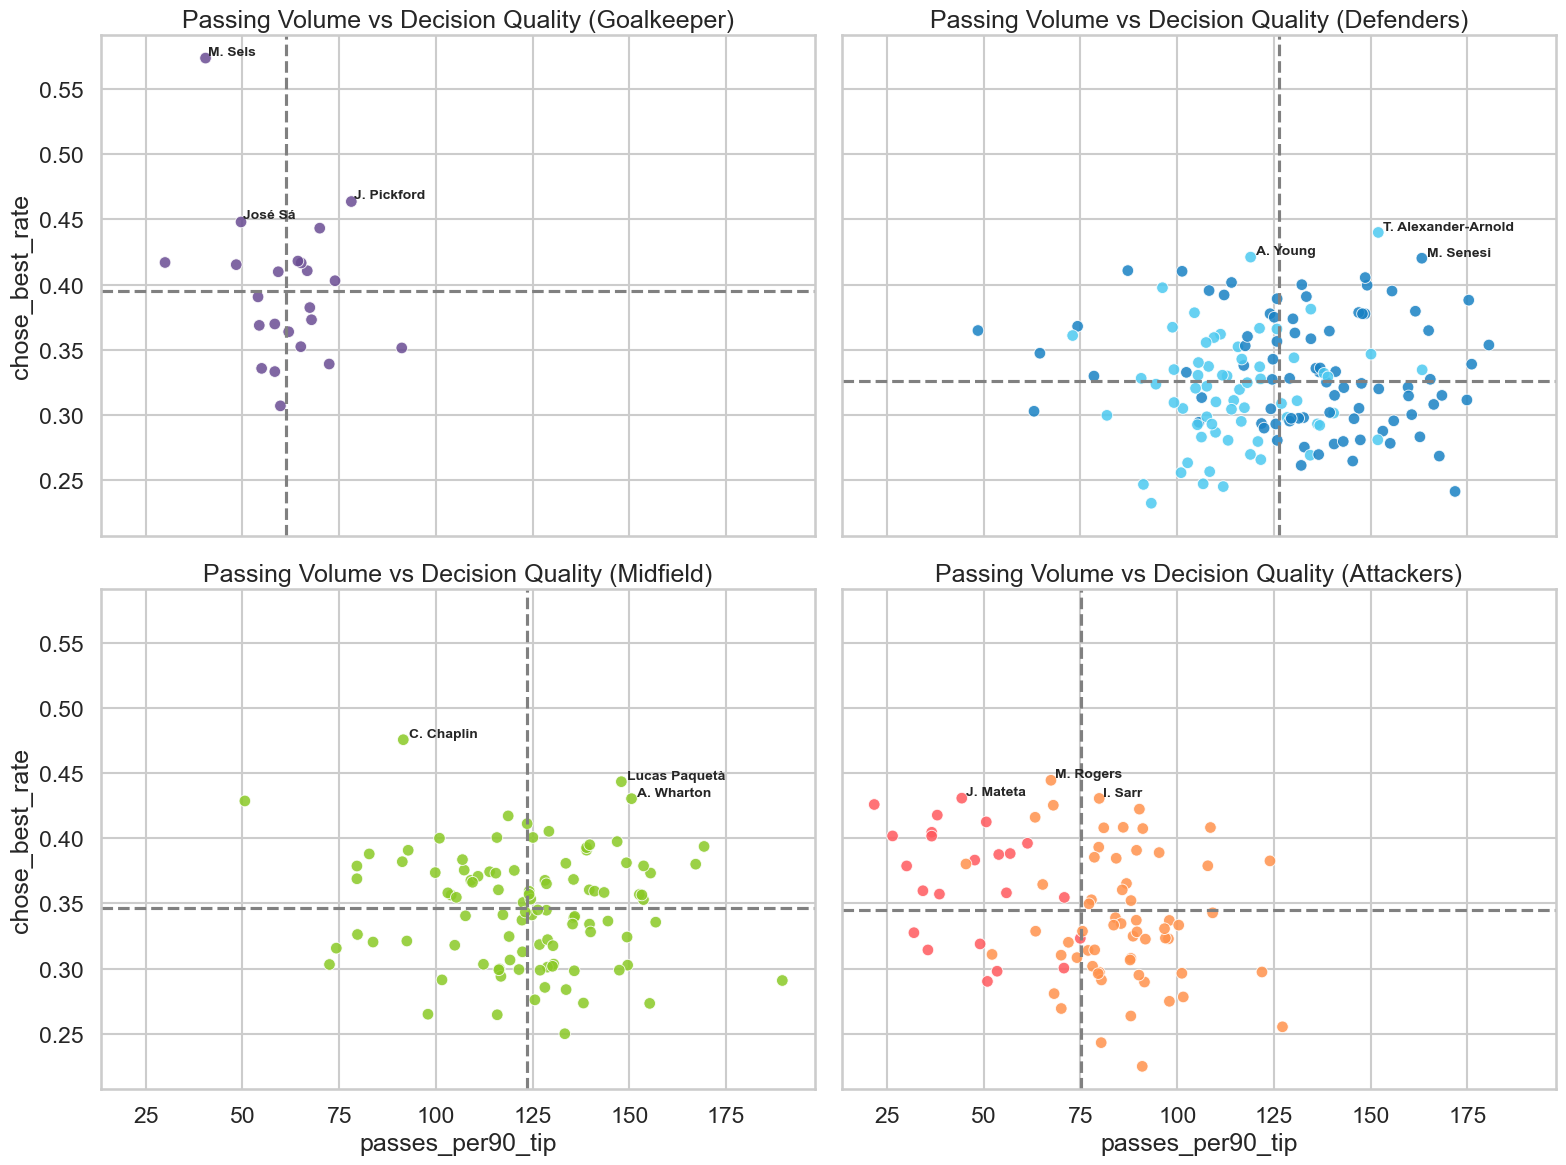

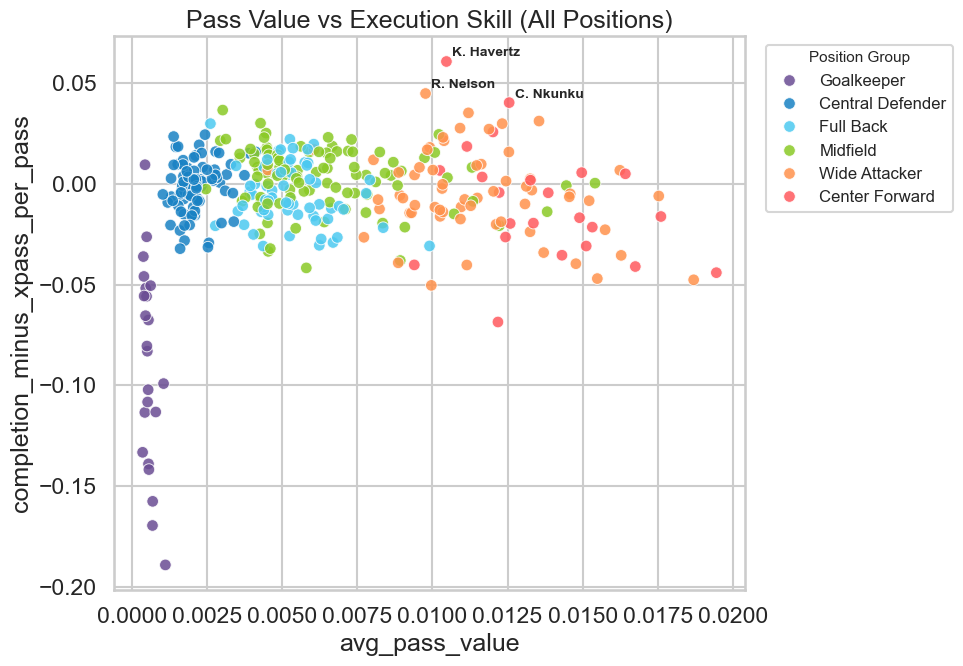

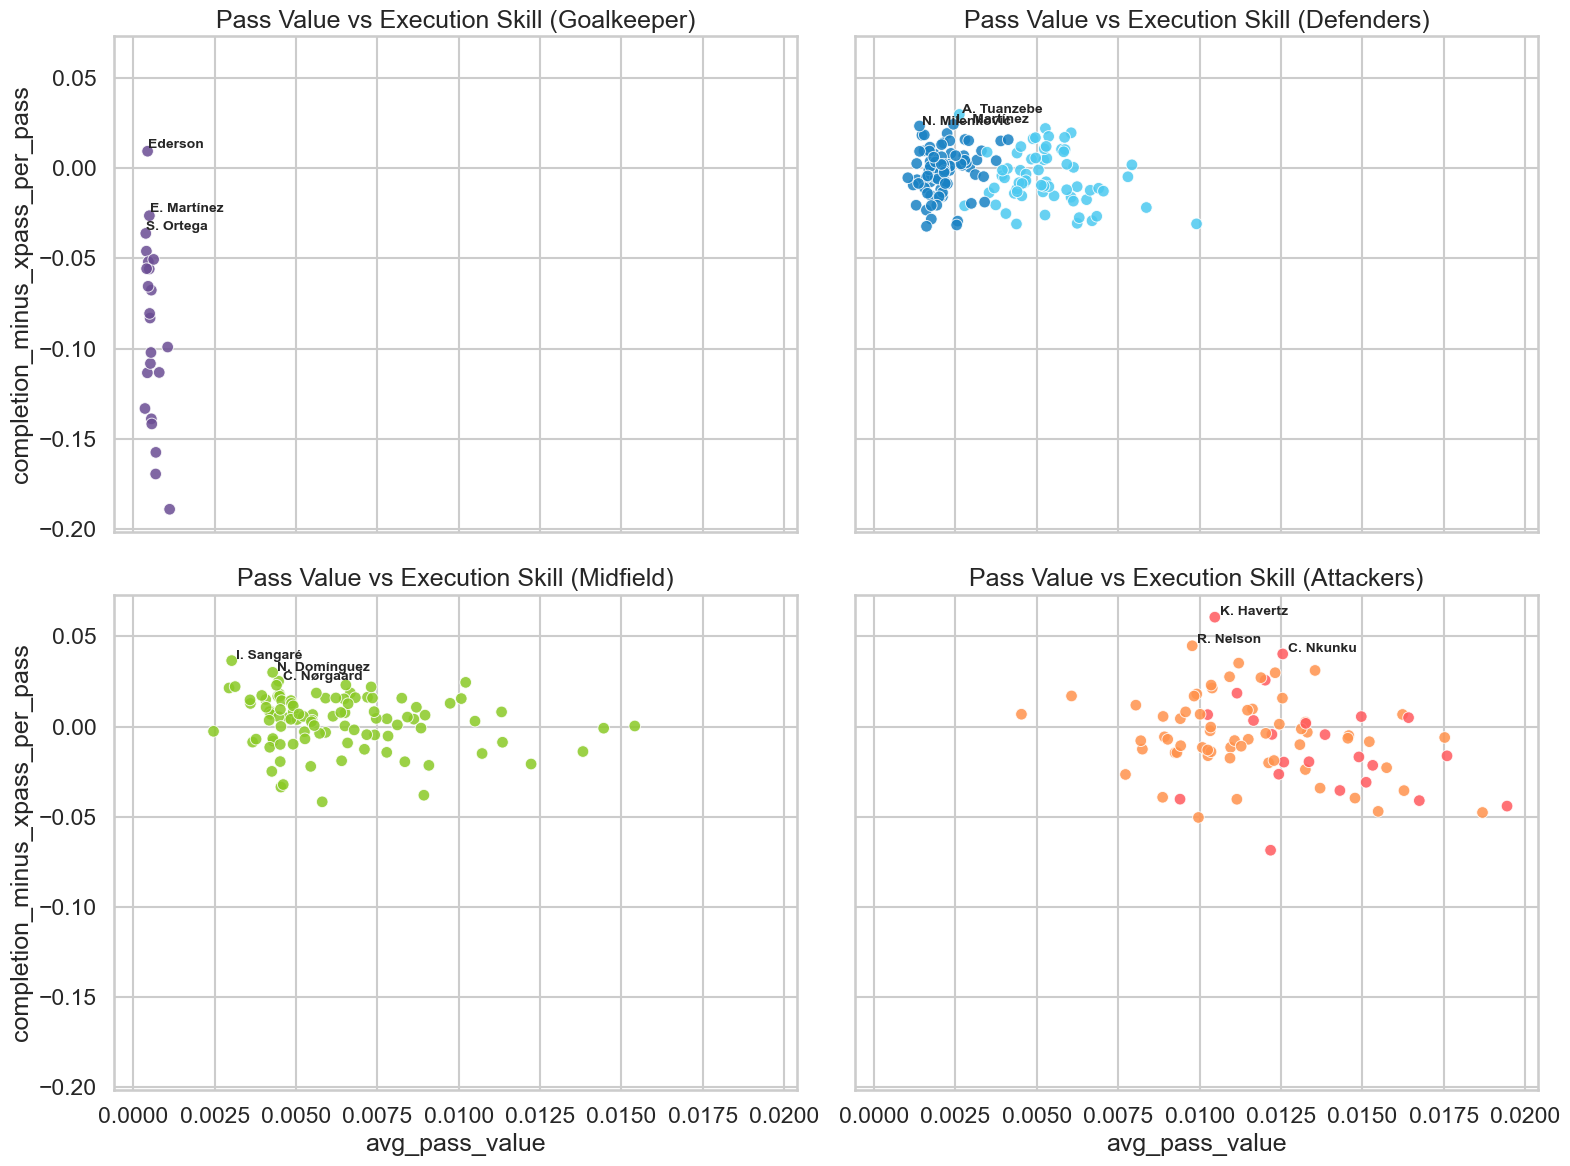

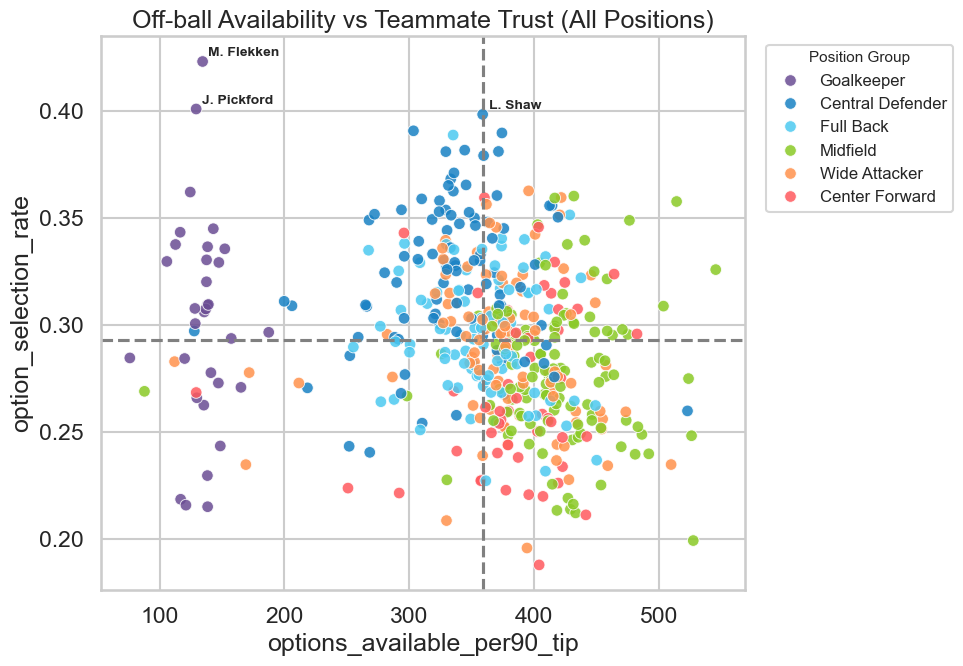

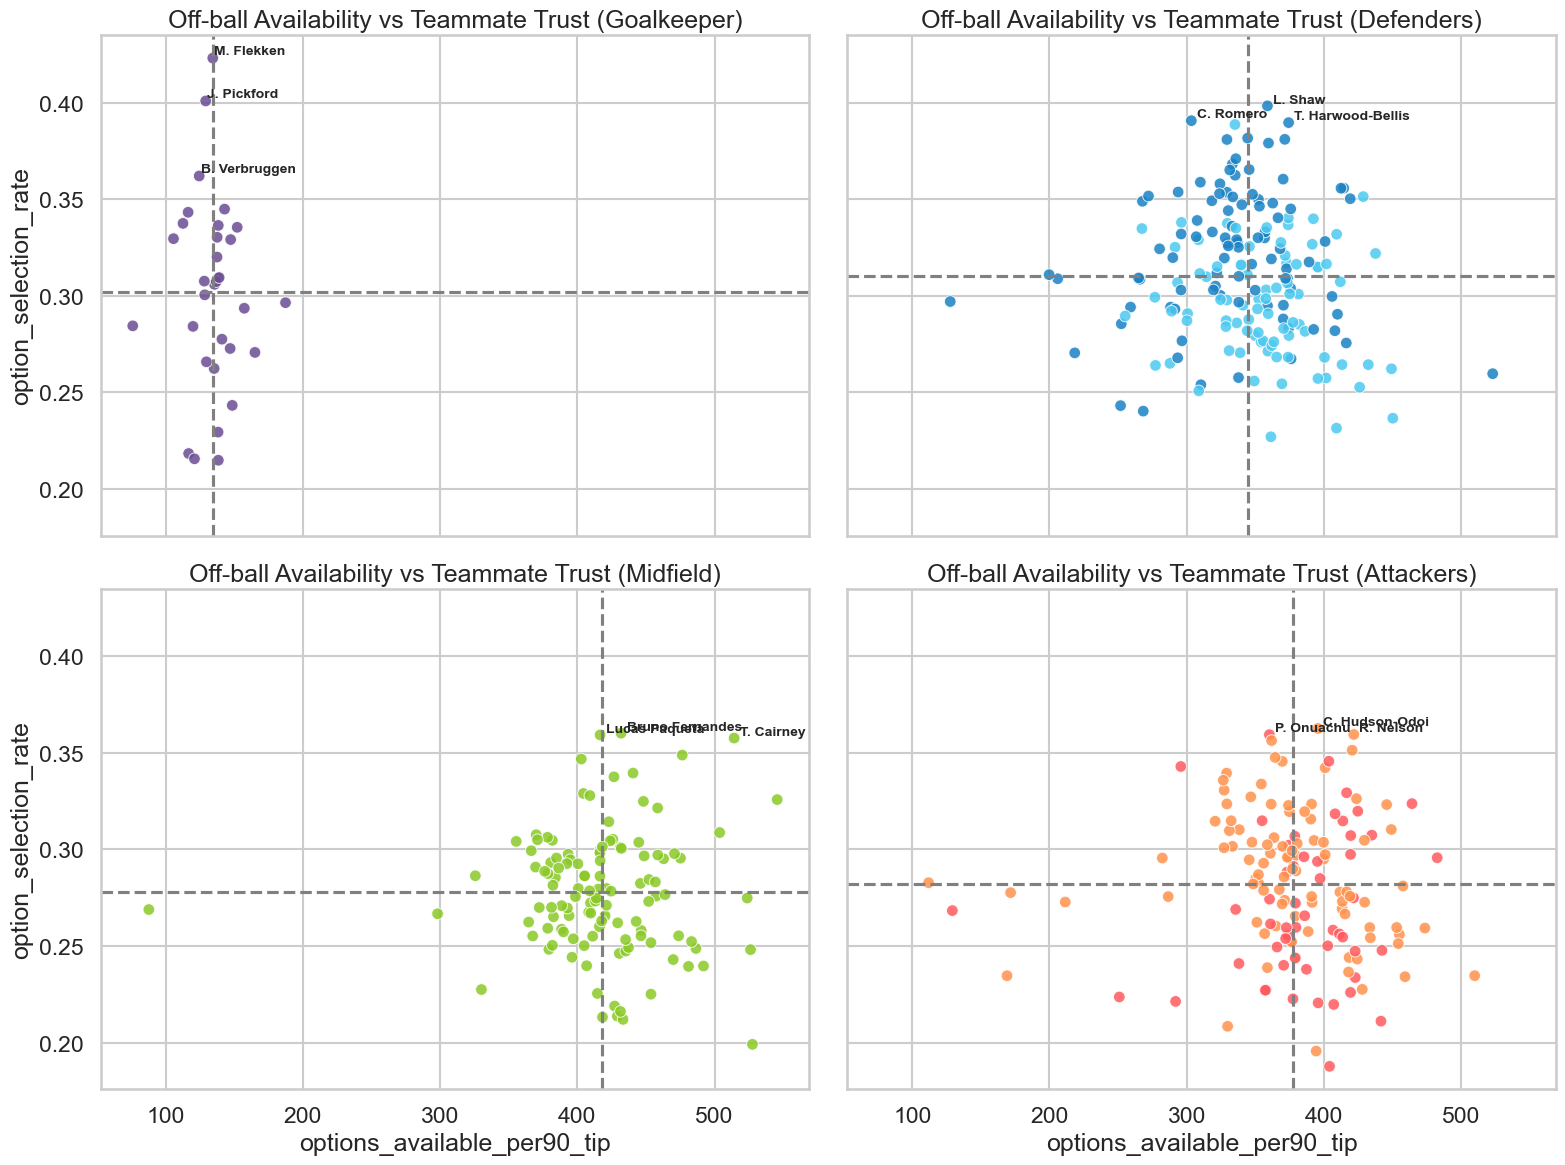

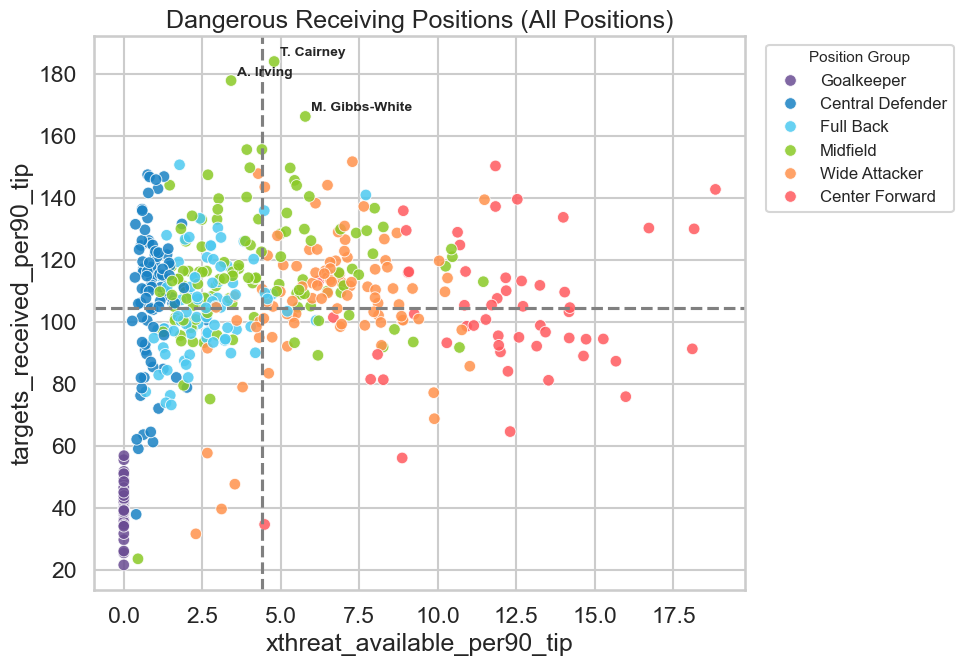

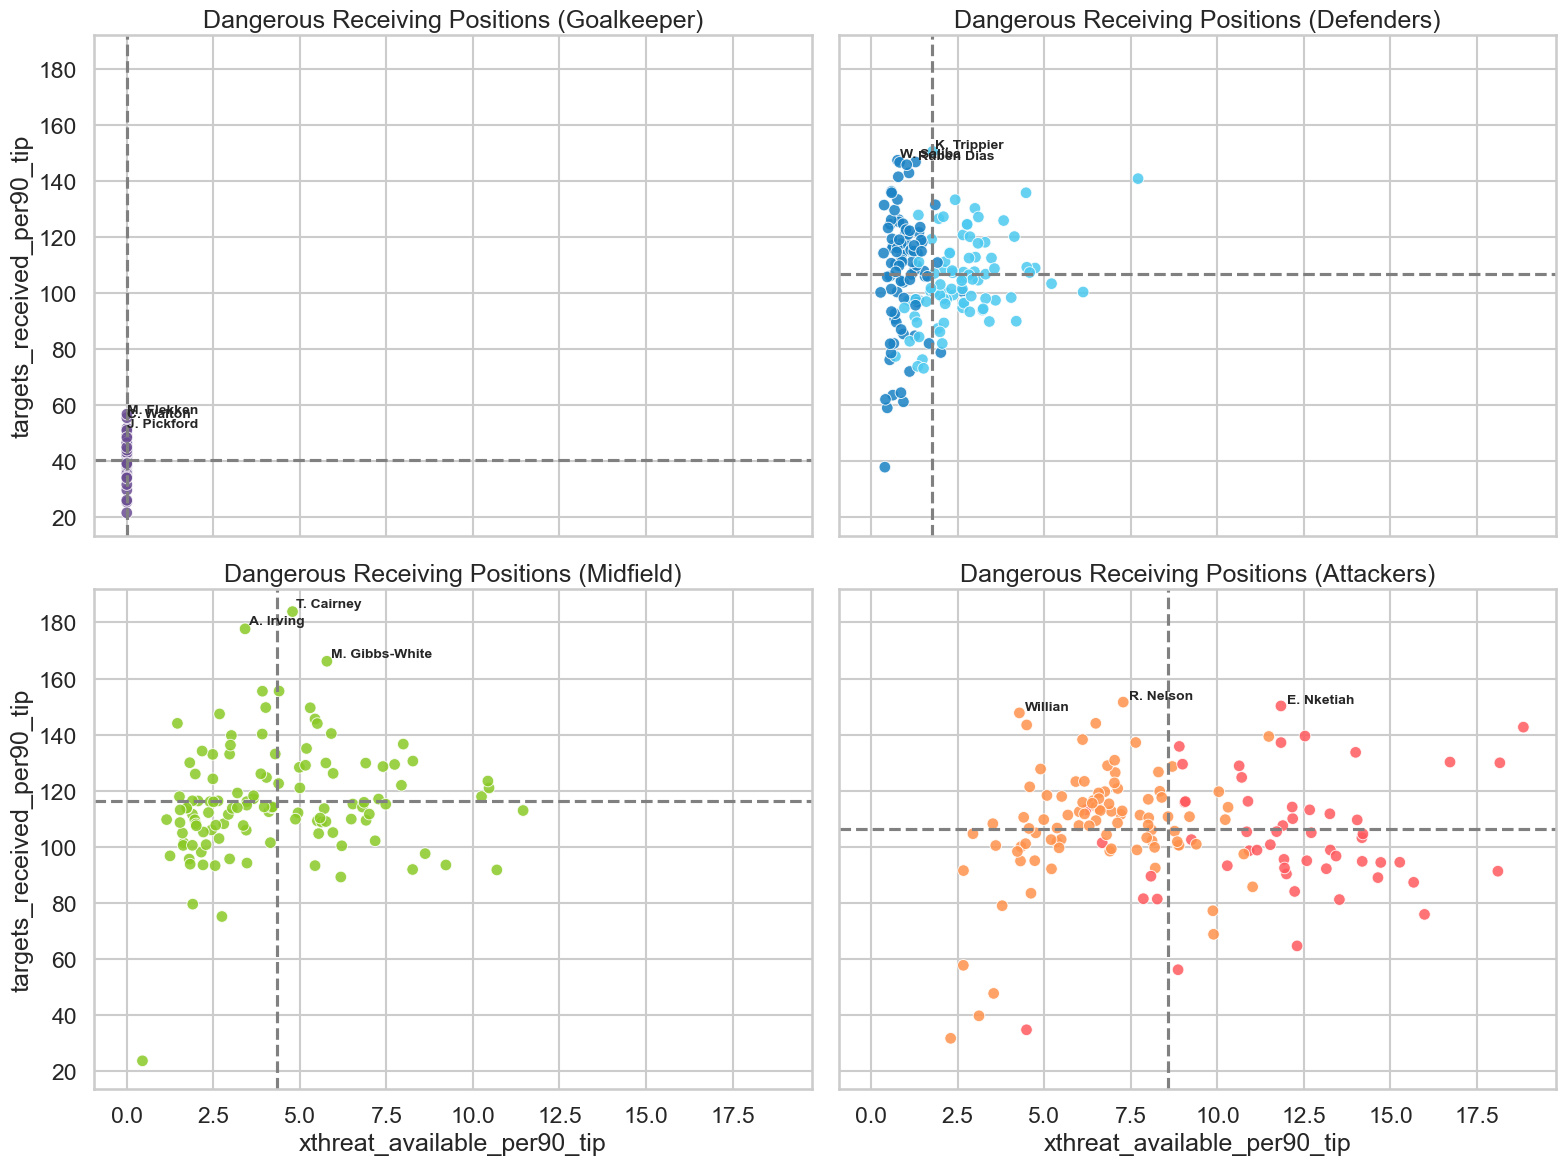

C:\Users\vicky\AppData\Local\Temp\ipykernel_13640\3465791279.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


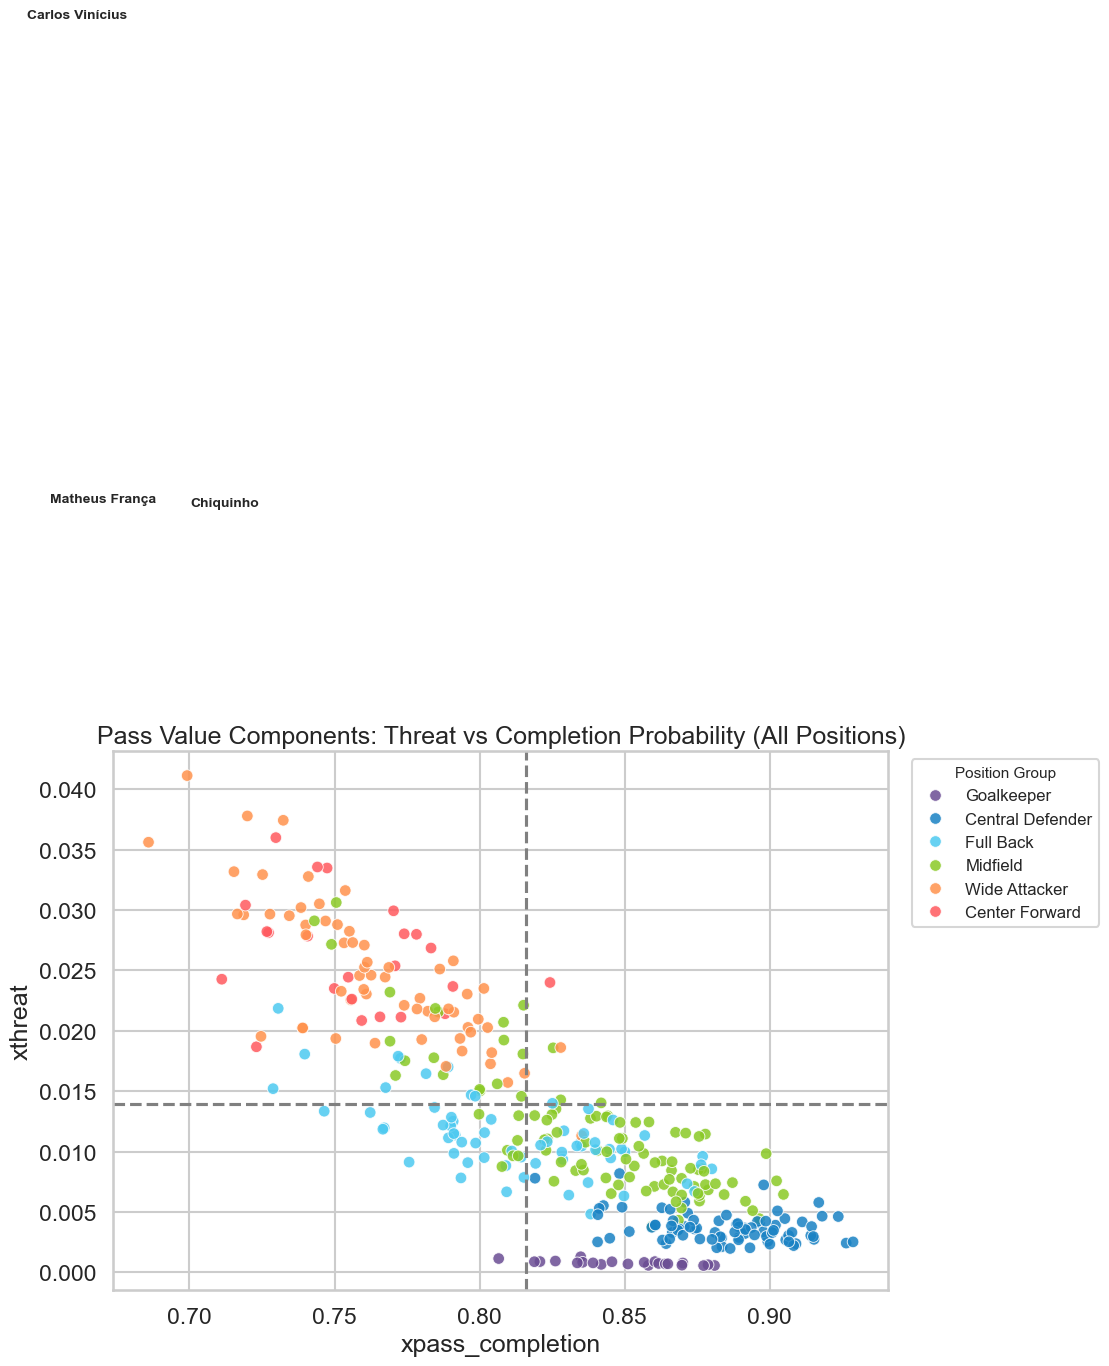

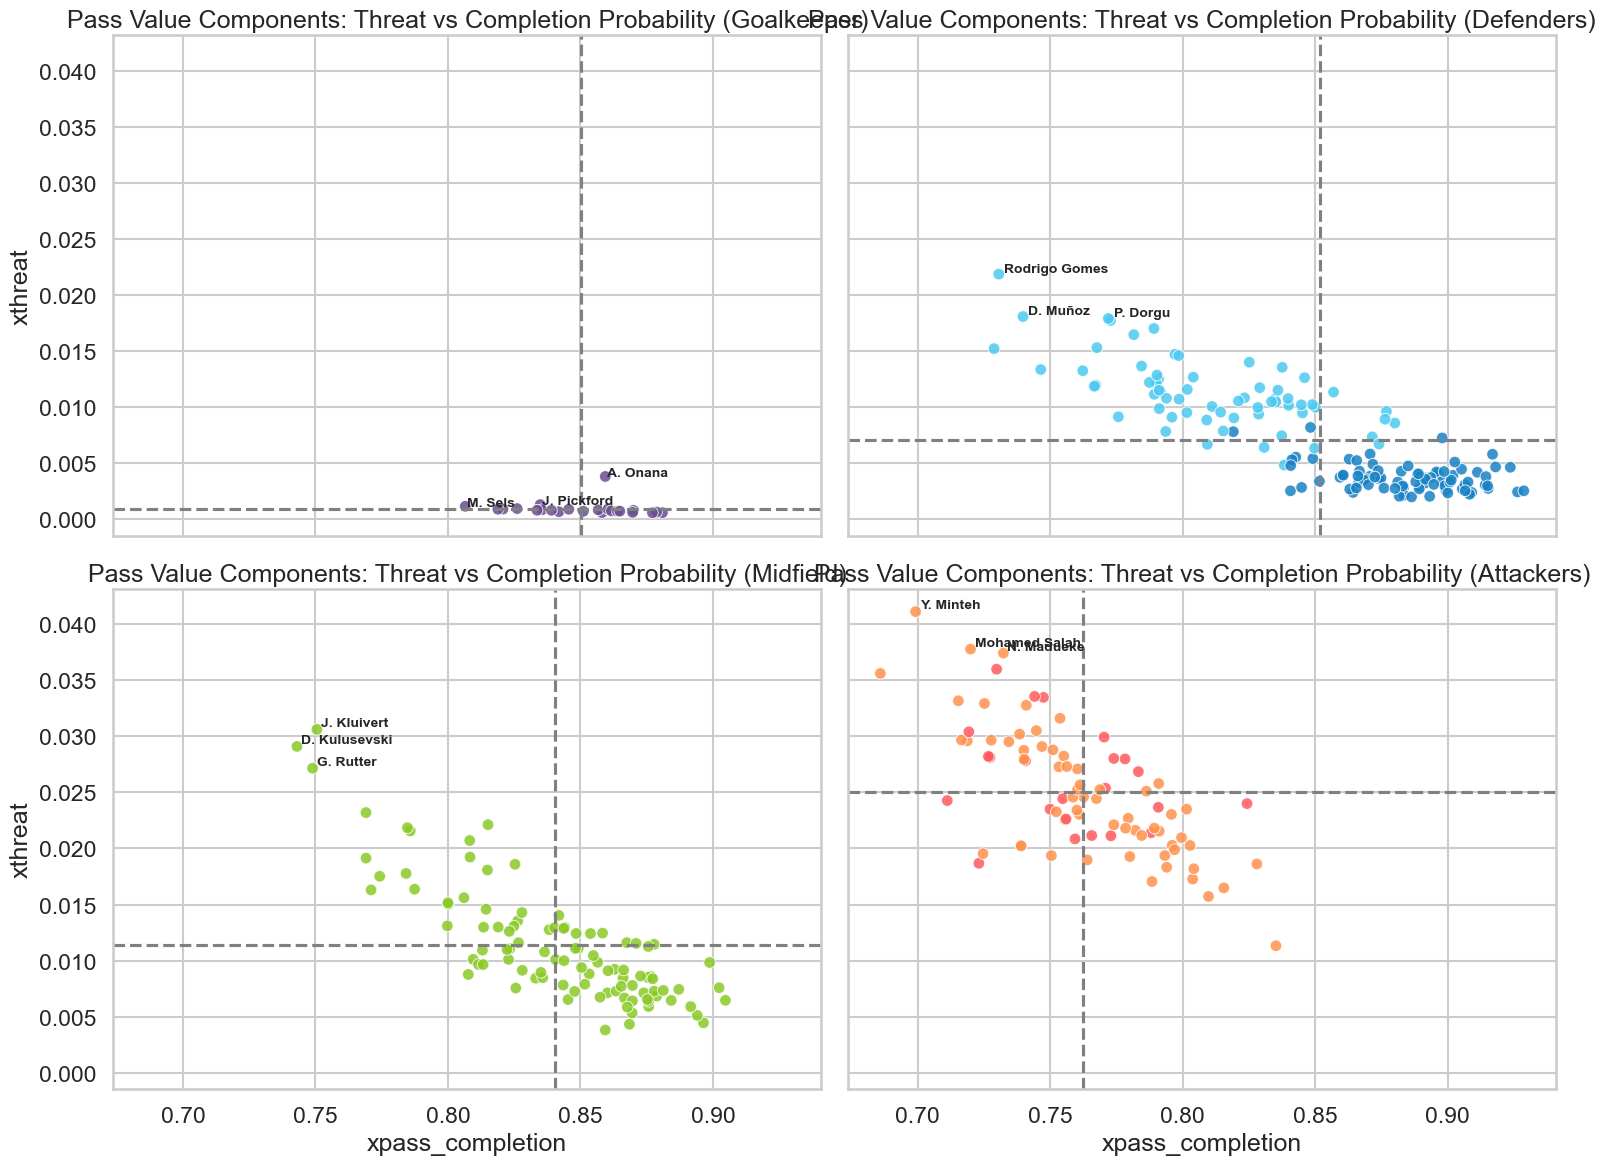

In [92]:
# ==========================================================
# 1. Passing Volume vs Decision Quality
# ==========================================================
plot_generic_and_clusters(
    df=passers_filtered,
    x="passes_per90_tip",
    y="chose_best_rate",
    label_col="passer_name",
    title="Passing Volume vs Decision Quality"
)

# ==========================================================
# 2. Pass Value vs Execution Skill
# ==========================================================
plot_generic_and_clusters(
    df=passers_filtered,
    x="avg_pass_value",
    y="completion_minus_xpass_per_pass",
    label_col="passer_name",
    title="Pass Value vs Execution Skill",
    ref_lines=False
)

# ==========================================================
# 3. Off-ball Availability vs Teammate Trust
# ==========================================================
plot_generic_and_clusters(
    df=receivers_filtered,
    x="options_available_per90_tip",
    y="option_selection_rate",
    label_col="receiver_name",
    title="Off-ball Availability vs Teammate Trust"
)

# ==========================================================
# 4. Dangerous Receiving Positions
# ==========================================================
plot_generic_and_clusters(
    df=receivers_filtered,
    x="xthreat_available_per90_tip",
    y="targets_received_per90_tip",
    label_col="receiver_name",
    title="Dangerous Receiving Positions"
)

# ==========================================================
# 5. Pass Value Components: Threat vs Completion Probability
# ==========================================================
plot_generic_and_clusters(
    df=passer_stats,
    x="xpass_completion",
    y="xthreat",
    label_col="passer_name",
    title="Pass Value Components: Threat vs Completion Probability"
)

         passer_name   xthreat  xpass_completion position_group
108  Carlos Vinícius  0.102809          0.638157            NaN
388   Matheus França  0.062733          0.646016            NaN
111        Chiquinho  0.062393          0.694227            NaN
91         C. Kporha  0.054420          0.725847            NaN
537         W. Osula  0.051259          0.697191            NaN
122         D. Malen  0.046486          0.726738            NaN
472    S. Amo-Ameyaw  0.045384          0.658347            NaN
477        S. Edozie  0.044518          0.691130            NaN
347          M. Godo  0.043637          0.691512            NaN
190        H. Howell  0.042604          0.789681            NaN


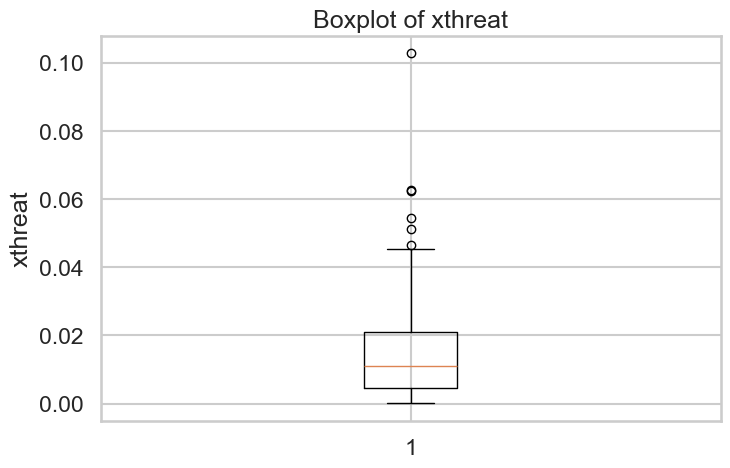

xthreat min/max: 0.000125 0.1028086956521739
xpass_completion min/max: 0.40493333333333337 0.9973333333333333


In [93]:
# 1. Look at the full data used for the plot
passer_stats.head(10)

# 2. Check summary statistics to see the range of xthreat and xpass_completion
passer_stats.describe()

# 3. Look at the top 10 xthreat values to see who might be "off the plot"
top_xthreat = passer_stats.nlargest(10, 'xthreat')
print(top_xthreat[['passer_name', 'xthreat', 'xpass_completion', 'position_group']])

# 4. Check for unusually high values (outliers)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.boxplot(passer_stats['xthreat'])
plt.title('Boxplot of xthreat')
plt.ylabel('xthreat')
plt.show()

# 5. Check the axis limits that matplotlib is using
print("xthreat min/max:", passer_stats['xthreat'].min(), passer_stats['xthreat'].max())
print("xpass_completion min/max:", passer_stats['xpass_completion'].min(), passer_stats['xpass_completion'].max())